# 环境测试 Notebook

用来验证 Python 3.12 + Jupyter 扩展是否正常工作。
逐个运行下面的代码块（点左侧的 ▶ 按钮，或按 Shift+Enter）。

In [1]:
# 测试 1：Python 版本与解释器路径
import sys, os
print("Python 版本:", sys.version)
# 路径中的用户名部分做脱敏显示，方便公开分享
print("解释器位置:", sys.executable.replace(os.path.expanduser("~"), "%USERPROFILE%"))


Python 版本: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
解释器位置: %USERPROFILE%\AppData\Local\Programs\Python\Python312\python.exe


In [2]:
# 测试 2：数据分析三件套是否可用
import numpy as np
import pandas as pd
import matplotlib

print("numpy 版本:", np.__version__)
print("pandas 版本:", pd.__version__)
print("matplotlib 版本:", matplotlib.__version__)

numpy 版本: 2.5.3
pandas 版本: 3.0.5
matplotlib 版本: 3.11.2


In [3]:
# 测试 3：跑一个真实的小数据分析
df = pd.DataFrame({
    "专业": ["广告学", "新闻学", "广播电视", "广告学", "新闻学"],
    "每周学习时长": [2.5, 3.0, 1.5, 2.0, 4.0],
    "作业得分": [88, 92, 79, 85, 95],
})

print("数据表：")
print(df)
print()
print("按专业汇总：")
print(df.groupby("专业")["作业得分"].mean())

数据表：
     专业  每周学习时长  作业得分
0   广告学     2.5    88
1   新闻学     3.0    92
2  广播电视     1.5    79
3   广告学     2.0    85
4   新闻学     4.0    95

按专业汇总：
专业
广告学     86.5
广播电视    79.0
新闻学     93.5
Name: 作业得分, dtype: float64


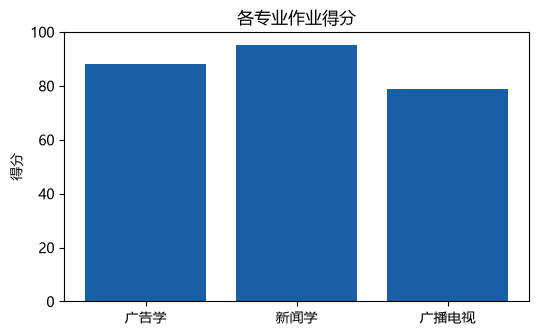

In [4]:
# 测试 4：画图（能显示出图就说明图表引擎正常）
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(6, 3.5))
plt.bar(df["专业"], df["作业得分"], color="#185FA5")
plt.title("各专业作业得分")
plt.ylabel("得分")
plt.ylim(0, 100)
plt.show()

In [5]:
# 测试 5：确认 pip 走的是国内源
import subprocess
out = subprocess.run([sys.executable, "-m", "pip", "config", "list"], capture_output=True, text=True)
print(out.stdout)

global.extra-index-url='https://mirrors.aliyun.com/pypi/simple/'
global.index-url='https://pypi.tuna.tsinghua.edu.cn/simple'
global.timeout='60'
global.trusted-host='pypi.tuna.tsinghua.edu.cn\nmirrors.aliyun.com'
install.upgrade-strategy='only-if-needed'

